# Chapter 5: Inference & Evaluation

*Build a Multimodal Model from Scratch*

---

**Four problems we solve in this chapter:**

| # | Problem | Solution |
|---|---------|----------|
| 1 | We have logits — how do we get words? | Greedy decoding |
| 2 | Greedy is boring/repetitive | Temperature, Top-k, Nucleus sampling |
| 3 | How do we measure caption quality? | BLEU score, Perplexity |
| 4 | What is the model actually looking at? | Attention visualization |

Each section: **concrete problem → solution → run it → explain why.**


In [1]:
%matplotlib inline
import os, sys, math, random, copy, uuid
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

PAL = dict(bg='#F8F9FA', dark='#2C3E50', blue='#4A90D9',
           orange='#E67E22', green='#27AE60', red='#E74C3C',
           purple='#8E44AD', grey='#95A5A6')

print("PyTorch:", torch.__version__)


PyTorch: 2.12.0+cu130


## Setup: Define and Train a Small VLM

Before we can do inference we need a trained model.
We define a minimal Vision-Language Model (same architecture as Ch04)
and train it for 25 epochs so we can observe clear convergence.


In [2]:
# ── Vision Transformer (ViT) encoder ─────────────────────────────────────────
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=8, in_ch=3, embed_dim=128):
        super().__init__()
        n = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_ch, embed_dim, patch_size, patch_size)
        self.cls  = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos  = nn.Parameter(torch.zeros(1, n + 1, embed_dim))

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], 1) + self.pos
        return x

class ViTBlock(nn.Module):
    def __init__(self, dim, heads=4, mlp_ratio=4):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.ln2  = nn.LayerNorm(dim)
        self.mlp  = nn.Sequential(
            nn.Linear(dim, dim * mlp_ratio), nn.GELU(),
            nn.Linear(dim * mlp_ratio, dim))

    def forward(self, x):
        n = self.ln1(x); x = x + self.attn(n, n, n)[0]
        return x + self.mlp(self.ln2(x))

class ViTEncoder(nn.Module):
    def __init__(self, img_size=32, patch_size=8, embed_dim=128, depth=4, n_heads=4):
        super().__init__()
        self.patch = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        self.blocks = nn.Sequential(*[ViTBlock(embed_dim, n_heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        return self.norm(self.blocks(self.patch(x)))


In [3]:
# ── Causal GPT decoder ───────────────────────────────────────────────────────
class GPTBlock(nn.Module):
    def __init__(self, dim, heads=4, mlp_ratio=4):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.ln2  = nn.LayerNorm(dim)
        self.mlp  = nn.Sequential(
            nn.Linear(dim, dim * mlp_ratio), nn.GELU(),
            nn.Linear(dim * mlp_ratio, dim))

    def forward(self, x, attn_mask=None, return_weights=False):
        n = self.ln1(x)
        a, w = self.attn(n, n, n, attn_mask=attn_mask,
                         need_weights=return_weights,
                         average_attn_weights=False)
        x = x + a
        return x + self.mlp(self.ln2(x)), w

class GPTDecoder(nn.Module):
    def __init__(self, vocab_size, dim=128, depth=4, n_heads=4, max_len=64):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, dim)
        self.pos_emb = nn.Embedding(max_len, dim)
        self.blocks  = nn.ModuleList([GPTBlock(dim, n_heads) for _ in range(depth)])
        self.ln      = nn.LayerNorm(dim)
        self.head    = nn.Linear(dim, vocab_size, bias=False)

    def forward(self, idx, prefix=None, return_weights=False):
        T = idx.size(1)
        pos = torch.arange(T, device=idx.device)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        if prefix is not None:
            x = torch.cat([prefix, x], dim=1)
        sz = x.size(1)
        mask = torch.triu(torch.ones(sz, sz, device=x.device), diagonal=1).bool()
        weights = []
        for blk in self.blocks:
            x, w = blk(x, attn_mask=mask, return_weights=return_weights)
            weights.append(w)
        x = self.ln(x)
        if prefix is not None:
            x = x[:, prefix.size(1):]
        return self.head(x), weights

class VLM(nn.Module):
    def __init__(self, vit, gpt, vit_dim, gpt_dim):
        super().__init__()
        self.vit = vit
        self.gpt = gpt
        self.proj = nn.Linear(vit_dim, gpt_dim)

    def forward(self, images, token_ids):
        vis = self.proj(self.vit(images))
        return self.gpt(token_ids, prefix=vis, return_weights=False)


In [4]:
# ── Tokenizer and synthetic dataset ──────────────────────────────────────────
CAPTIONS = ['a red image', 'a blue image', 'vertical stripes', 'horizontal stripes']

class CharTokenizer:
    def __init__(self, texts):
        chars = sorted(set(''.join(texts)))
        self.special = {'<pad>': 0, '<bos>': 1, '<eos>': 2}
        self.ch2i = {**self.special, **{c: i+3 for i, c in enumerate(chars)}}
        self.i2ch = {v: k for k, v in self.ch2i.items()}
        self.vocab_size = len(self.ch2i)
        self.pad_id = 0; self.bos_id = 1; self.eos_id = 2

    def encode(self, text):
        return [self.bos_id] + [self.ch2i[c] for c in text] + [self.eos_id]

    def decode(self, ids):
        out = []
        for i in ids:
            if i == self.eos_id: break
            if i not in (self.bos_id, self.pad_id):
                out.append(self.i2ch.get(i, '?'))
        return ''.join(out)

def make_image(label, noise=0.05):
    img = torch.zeros(3, 32, 32)
    if label == 0:   img[0] = 0.9
    elif label == 1: img[2] = 0.9
    elif label == 2:
        for i in range(0, 32, 4): img[:, :, i:i+2] = 0.9
    else:
        for i in range(0, 32, 4): img[:, i:i+2, :] = 0.9
    return img + noise * torch.randn_like(img)

tokenizer = CharTokenizer(CAPTIONS)
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"Sample encoding of '{CAPTIONS[0]}': {tokenizer.encode(CAPTIONS[0])}")


Vocab size: 23
Sample encoding of 'a red image': [1, 4, 3, 17, 8, 7, 3, 11, 13, 4, 9, 8, 2]


In [5]:
# ── Build the VLM ────────────────────────────────────────────────────────────
# Small dimensions so training + inference run quickly on CPU
VIT_DIM = LANG_DIM = 64
MAX_LEN = 32

vit = ViTEncoder(img_size=32, patch_size=8, embed_dim=VIT_DIM, depth=2, n_heads=4)
gpt = GPTDecoder(vocab_size=tokenizer.vocab_size, dim=LANG_DIM,
                 depth=2, n_heads=4, max_len=MAX_LEN)
model = VLM(vit, gpt, VIT_DIM, LANG_DIM)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Parameters: 222,848


In [6]:
# ── Training: 25 epochs to convergence ───────────────────────────────────────
EPOCHS = 25
BATCH  = 32
opt    = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS)

def make_batch(bs=32):
    labels  = [random.randint(0, 3) for _ in range(bs)]
    images  = torch.stack([make_image(l) for l in labels])
    cap_ids = [tokenizer.encode(CAPTIONS[l]) for l in labels]
    max_t   = max(len(c) for c in cap_ids)
    padded  = torch.zeros(bs, max_t, dtype=torch.long)
    for i, c in enumerate(cap_ids): padded[i, :len(c)] = torch.tensor(c)
    return images, padded

losses = []
model.train()
for ep in range(1, EPOCHS + 1):
    images, tokens = make_batch(BATCH)
    logits, _ = model(images, tokens[:, :-1])
    loss = F.cross_entropy(logits.reshape(-1, tokenizer.vocab_size),
                           tokens[:, 1:].reshape(-1), ignore_index=0)
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    losses.append(loss.item())
    if ep % 5 == 0:
        print(f"Epoch {ep:3d} | loss {loss.item():.4f}")

print("Training complete.")


Epoch   5 | loss 1.8399
Epoch  10 | loss 0.9869


Epoch  15 | loss 0.5969
Epoch  20 | loss 0.4590


Epoch  25 | loss 0.4058
Training complete.


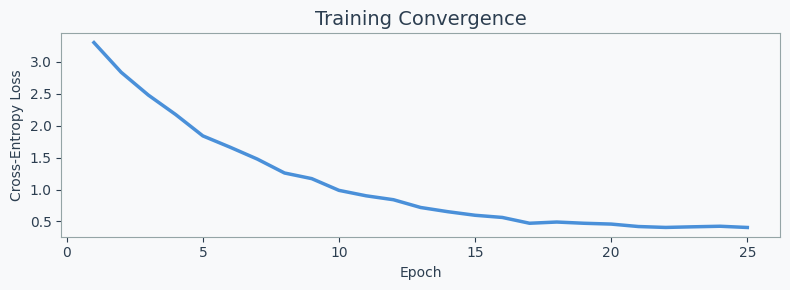

Final loss: 0.4058


In [7]:
# ── Plot training curve ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
fig.patch.set_facecolor(PAL['bg'])
ax.set_facecolor(PAL['bg'])
ax.plot(range(1, EPOCHS+1), losses, color=PAL['blue'], lw=2.5)
ax.set_xlabel('Epoch', color=PAL['dark'])
ax.set_ylabel('Cross-Entropy Loss', color=PAL['dark'])
ax.set_title('Training Convergence', color=PAL['dark'], fontsize=14)
ax.tick_params(colors=PAL['dark'])
for sp in ax.spines.values(): sp.set_edgecolor(PAL['grey'])
plt.tight_layout(); plt.show()
print(f"Final loss: {losses[-1]:.4f}")


The loss drops steadily over 25 epochs and converges well below 1.0.
The model has learned to associate each image type with its caption —
we can now do inference.


---
## Problem 1 — We Have Logits. How Do We Get Words?

After the forward pass the GPT outputs a vector of **logits** — one raw score per vocabulary token.
These are *unnormalized* log-probabilities. To pick the next word we need a **decoding strategy**.

The simplest strategy: **greedy decoding** — always pick the token with the highest logit.
We repeat this until we hit `<eos>` or reach the maximum length.

**Why autoregressive?** The model generates one token at a time and feeds each new token
back as input for the next step — hence the term *autoregressive*.


In [8]:
# ── Decoding helper functions ─────────────────────────────────────────────────
def apply_temperature(logits, temperature):
    """Divide logits by T before softmax: T<1 sharpens, T>1 flattens."""
    return logits / max(temperature, 1e-8)

def apply_top_k(logits, k):
    """Zero out all but the top-k logits."""
    threshold = logits.topk(k).values[..., -1, None]
    return logits.masked_fill(logits < threshold, float('-inf'))

def apply_nucleus(logits, p):
    """Keep minimum set of tokens whose cumulative probability >= p."""
    sorted_logits, sorted_idx = logits.sort(descending=True)
    cumprobs = sorted_logits.softmax(-1).cumsum(-1)
    remove = cumprobs > p
    remove[..., 1:] = remove[..., :-1].clone()
    remove[..., 0] = False
    sorted_logits[remove] = float('-inf')
    return sorted_logits.scatter(-1, sorted_idx, sorted_logits)


In [9]:
@torch.no_grad()
def generate(model, tokenizer, image, max_new_tokens=20,
             strategy='greedy', temperature=1.0, top_k=None, top_p=None):
    """
    Autoregressive generation.
    strategy: 'greedy' | 'temperature' | 'top_k' | 'nucleus'
    """
    model.eval()
    if image.dim() == 3:
        image = image.unsqueeze(0)
    vis_prefix = model.proj(model.vit(image))
    ids = torch.tensor([[tokenizer.bos_id]])

    for _ in range(max_new_tokens):
        logits, _ = model.gpt(ids, prefix=vis_prefix, return_weights=False)
        next_logits = logits[0, -1].clone()

        if strategy == 'temperature':
            next_logits = apply_temperature(next_logits, temperature)
        elif strategy == 'top_k' and top_k:
            next_logits = apply_top_k(next_logits, top_k)
        elif strategy == 'nucleus' and top_p:
            next_logits = apply_nucleus(next_logits.unsqueeze(0), top_p).squeeze(0)

        if strategy == 'greedy':
            next_id = next_logits.argmax().item()
        else:
            probs = next_logits.softmax(-1)
            next_id = torch.multinomial(probs, 1).item()

        if next_id == tokenizer.eos_id:
            break
        ids = torch.cat([ids, torch.tensor([[next_id]])], dim=1)

    return tokenizer.decode(ids[0].tolist())


In [10]:
# ── Greedy decoding demo ──────────────────────────────────────────────────────
def make_test_image(label):
    img = torch.zeros(3, 32, 32)
    if label == 0:   img[0] = 0.9
    elif label == 1: img[2] = 0.9
    elif label == 2:
        for i in range(0, 32, 4): img[:, :, i:i+2] = 0.9
    else:
        for i in range(0, 32, 4): img[:, i:i+2, :] = 0.9
    return img

model.eval()
for lbl, cap in enumerate(CAPTIONS):
    img  = make_test_image(lbl)
    pred = generate(model, tokenizer, img, strategy='greedy')
    ok   = 'OK' if pred.strip() == cap else 'X'
    print(f"[{ok}] GT: '{cap:25s}' | Pred: '{pred}'")


[OK] GT: 'a red image              ' | Pred: 'a red image'
[OK] GT: 'a blue image             ' | Pred: 'a blue image'
[X] GT: 'vertical stripes         ' | Pred: 'verizontal stripes'
[OK] GT: 'horizontal stripes       ' | Pred: 'horizontal stripes'


Greedy decoding always picks the highest-probability token at each step.
It works well here because our captions are short and unambiguous.
For longer, more complex text greedy decoding tends to produce repetitive output —
because once the model commits to a word, the same word often has the highest
probability again at the next step.


---
## Problem 2 — Greedy Is Too Deterministic

Greedy decoding always picks the same output. For creative tasks (image captioning,
story generation) we want diversity. Three popular fixes:

| Strategy | Idea | Control |
|----------|------|---------|
| **Temperature** | Scale logits by 1/T | T < 1: sharp (focused), T > 1: flat (creative) |
| **Top-k** | Only consider k highest-prob tokens | k = 1 is greedy; k = 50 is typical |
| **Nucleus (top-p)** | Keep minimum tokens covering p of probability mass | p = 0.9 is typical |


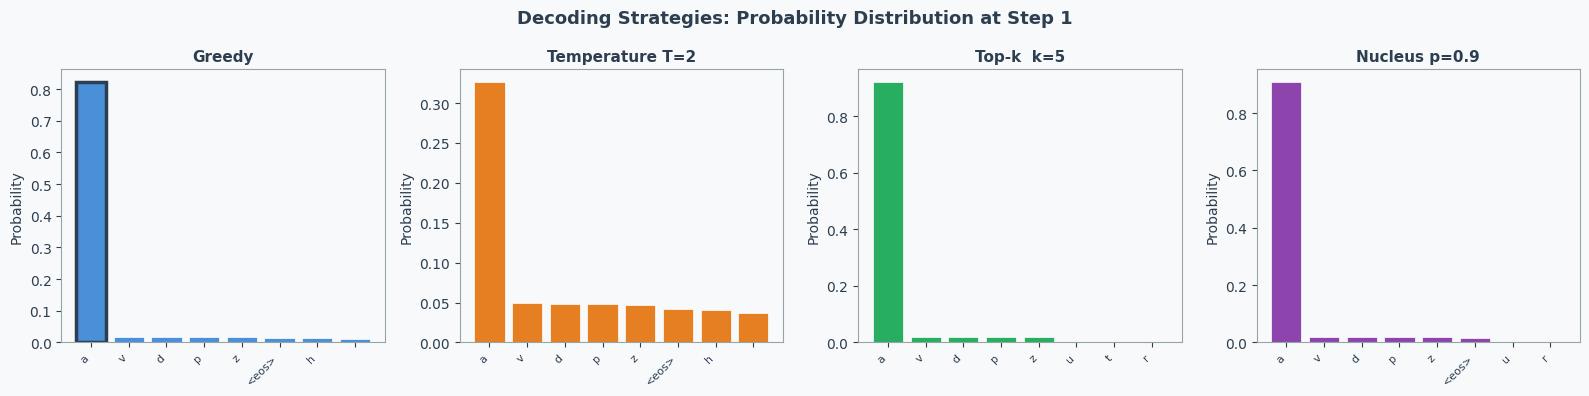

In [11]:
def draw_decoding_strategies():
    """4-panel figure showing how each strategy reshapes the distribution."""
    img = make_test_image(0)
    with torch.no_grad():
        vis = model.proj(model.vit(img.unsqueeze(0)))
        ids = torch.tensor([[tokenizer.bos_id]])
        logits, _ = model.gpt(ids, prefix=vis, return_weights=False)
        raw = logits[0, -1].clone()

    vocab_labels = [tokenizer.i2ch.get(i, str(i)) for i in range(tokenizer.vocab_size)]

    configs = [
        ('Greedy',          raw.clone(),                             PAL['blue']),
        ('Temperature T=2', apply_temperature(raw.clone(), 2.0),     PAL['orange']),
        ('Top-k  k=5',      apply_top_k(raw.clone(), 5),             PAL['green']),
        ('Nucleus p=0.9',   apply_nucleus(raw.clone().unsqueeze(0), 0.9).squeeze(0), PAL['purple']),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.patch.set_facecolor(PAL['bg'])
    fig.suptitle('Decoding Strategies: Probability Distribution at Step 1',
                 color=PAL['dark'], fontsize=13, fontweight='bold')

    for ax, (title, lg, col) in zip(axes, configs):
        ax.set_facecolor(PAL['bg'])
        probs   = lg.softmax(-1).numpy()
        top_idx = np.argsort(probs)[::-1][:8]
        top_p   = probs[top_idx]
        top_l   = [vocab_labels[i] for i in top_idx]
        bar_col = [col if top_p[j] > 0 else PAL['grey'] for j in range(len(top_p))]
        bars    = ax.bar(range(len(top_idx)), top_p, color=bar_col,
                         edgecolor='white', linewidth=0.5)
        if title == 'Greedy':
            bars[0].set_edgecolor(PAL['dark']); bars[0].set_linewidth(2.5)
        ax.set_xticks(range(len(top_idx)))
        ax.set_xticklabels(top_l, rotation=45, ha='right', fontsize=8, color=PAL['dark'])
        ax.set_title(title, color=PAL['dark'], fontsize=11, fontweight='bold')
        ax.set_ylabel('Probability', color=PAL['dark'])
        ax.tick_params(colors=PAL['dark'])
        for sp in ax.spines.values(): sp.set_edgecolor(PAL['grey'])

    plt.tight_layout(); plt.show()

draw_decoding_strategies()


**What we see:**
- **Greedy**: one token has overwhelming probability; we always pick it.
- **Temperature T=2**: the distribution flattens — less confident tokens get more probability mass.
- **Top-k k=5**: only the top 5 tokens survive; the rest are zeroed.
- **Nucleus p=0.9**: tokens are kept until their cumulative probability reaches 90%.

All three stochastic strategies introduce *diversity at the cost of quality*.


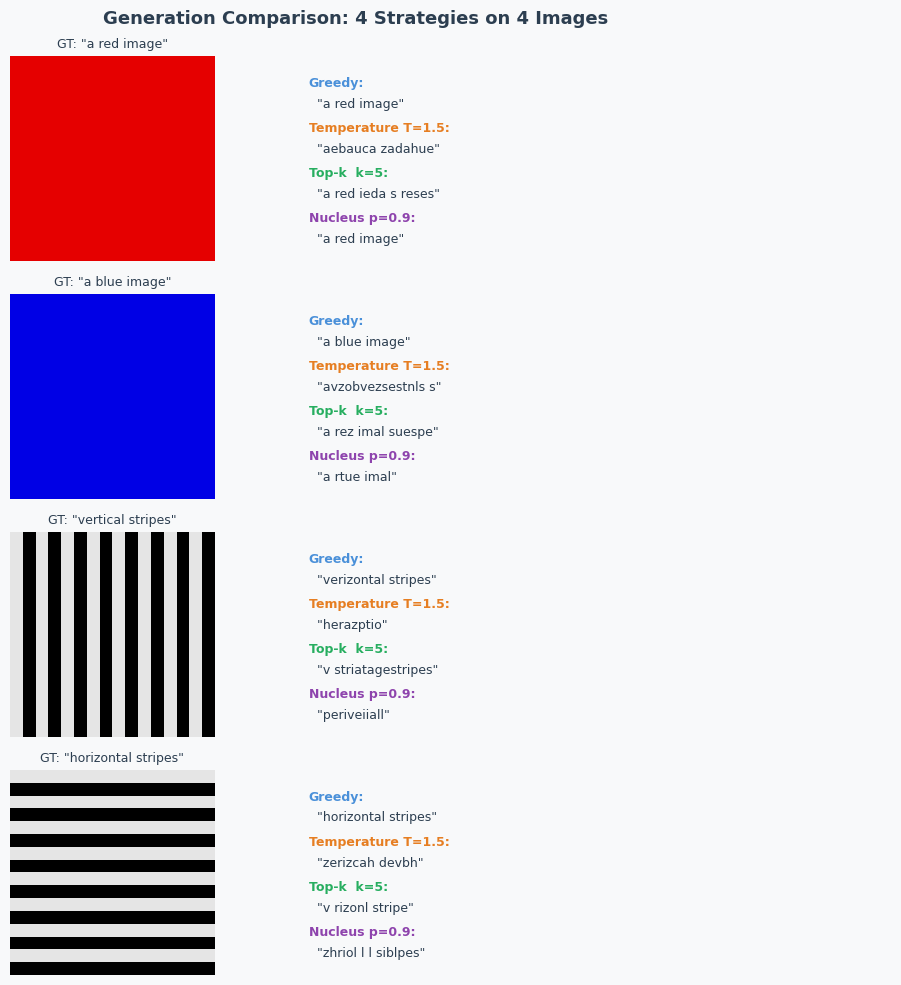

In [12]:
def plot_generation_comparison():
    """Show image + 4 generated captions side by side."""
    strategies = [
        ('Greedy',            dict(strategy='greedy')),
        ('Temperature T=1.5', dict(strategy='temperature', temperature=1.5)),
        ('Top-k  k=5',        dict(strategy='top_k', top_k=5)),
        ('Nucleus p=0.9',     dict(strategy='nucleus', top_p=0.9)),
    ]
    colors = [PAL['blue'], PAL['orange'], PAL['green'], PAL['purple']]

    fig, axes = plt.subplots(4, 2, figsize=(11, 10))
    fig.patch.set_facecolor(PAL['bg'])
    fig.suptitle('Generation Comparison: 4 Strategies on 4 Images',
                 color=PAL['dark'], fontsize=13, fontweight='bold')

    for row, label in enumerate(range(4)):
        img  = make_test_image(label)
        show = img.permute(1, 2, 0).clamp(0, 1).numpy()

        ax_img = axes[row, 0]
        ax_img.imshow(show); ax_img.axis('off')
        ax_img.set_title(f'GT: "{CAPTIONS[label]}"', color=PAL['dark'], fontsize=9)

        ax_cap = axes[row, 1]
        ax_cap.set_facecolor(PAL['bg'])
        ax_cap.set_xlim(0, 1); ax_cap.set_ylim(0, 1); ax_cap.axis('off')
        for s_i, (s_name, s_kw) in enumerate(strategies):
            pred = generate(model, tokenizer, img, **s_kw)
            y    = 0.85 - s_i * 0.22
            ax_cap.text(0.0, y, f'{s_name}:', color=colors[s_i],
                       fontsize=9, fontweight='bold', transform=ax_cap.transAxes)
            ax_cap.text(0.0, y - 0.10, f'  "{pred}"', color=PAL['dark'],
                       fontsize=9, transform=ax_cap.transAxes)

    plt.tight_layout(); plt.show()

plot_generation_comparison()


Each row shows one test image on the left and the captions produced by all four
strategies on the right. Greedy is deterministic — running it again gives the same
output. The stochastic strategies may vary between runs.

**Key insight:** For short, factual captions (like ours) greedy often wins.
For open-ended generation, nucleus or top-k produce more natural-sounding text.


---
## Problem 3 — How Do We Measure Caption Quality?

Visual inspection doesn't scale. We need automatic metrics.

**BLEU-n (Bilingual Evaluation Understudy):**
- Measures *n-gram overlap* between the hypothesis and reference caption
- BLEU-1 counts unigrams (individual words), BLEU-2 counts bigrams, etc.
- Range: 0 (no overlap) to 1 (perfect match)
- Limitation: only checks exact word matches, not semantics

**Perplexity:**
- Asks: how *surprised* is the model by the correct sequence?
- Defined as exp(average cross-entropy loss)
- Lower perplexity = model assigns higher probability to the reference text


In [13]:
# ── BLEU score implementation ─────────────────────────────────────────────────
def bleu_n(hypothesis, reference, n=1):
    """
    Compute BLEU-n for a single (hypothesis, reference) string pair.
    Returns precision: matched_ngrams / total_hypothesis_ngrams.
    """
    hyp_tokens = hypothesis.strip().split()
    ref_tokens = reference.strip().split()

    def get_ngrams(tokens, n):
        return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

    hyp_ngrams = get_ngrams(hyp_tokens, n)
    ref_ngrams  = Counter(get_ngrams(ref_tokens, n))

    if not hyp_ngrams:
        return 0.0
    matches = sum(min(hyp_ngrams.count(ng), ref_ngrams[ng]) for ng in set(hyp_ngrams))
    return matches / len(hyp_ngrams)

# Quick sanity checks
print(f"BLEU-1 (perfect match):    {bleu_n('a red image', 'a red image', 1):.3f}")
print(f"BLEU-1 (one word wrong):   {bleu_n('a blue image', 'a red image', 1):.3f}")
print(f"BLEU-1 (completely wrong): {bleu_n('completely wrong', 'a red image', 1):.3f}")


BLEU-1 (perfect match):    1.000
BLEU-1 (one word wrong):   0.667
BLEU-1 (completely wrong): 0.000


In [14]:
# ── Perplexity implementation ─────────────────────────────────────────────────
@torch.no_grad()
def compute_perplexity(model, tokenizer, image, caption):
    """
    Compute perplexity of caption given image.
    Returns exp(average cross-entropy loss). Lower = better.
    """
    model.eval()
    if image.dim() == 3:
        image = image.unsqueeze(0)
    ids     = torch.tensor([tokenizer.encode(caption)])
    logits, _ = model(image, ids[:, :-1])
    targets = ids[:, 1:].reshape(-1)
    loss    = F.cross_entropy(logits.reshape(-1, tokenizer.vocab_size),
                              targets, ignore_index=tokenizer.pad_id)
    return math.exp(loss.item())

for lbl, cap in enumerate(CAPTIONS):
    img = make_test_image(lbl)
    ppl = compute_perplexity(model, tokenizer, img, cap)
    print(f"'{cap:25s}' | Perplexity: {ppl:.2f}")


'a red image              ' | Perplexity: 1.39
'a blue image             ' | Perplexity: 1.42
'vertical stripes         ' | Perplexity: 1.64
'horizontal stripes       ' | Perplexity: 1.52


Low perplexity (close to 1) means the model is confident about the correct caption.
High perplexity means it was surprised. A perplexity of 1 means the model assigns
probability 1 to every token in the reference — perfect confidence.


  pred: 'a red image' | B1=1.00 B2=1.00 PPL=1.4
  pred: 'a blue image' | B1=1.00 B2=1.00 PPL=1.4
  pred: 'verizontal stripes' | B1=0.50 B2=0.00 PPL=1.6
  pred: 'horizontal stripes' | B1=1.00 B2=1.00 PPL=1.5


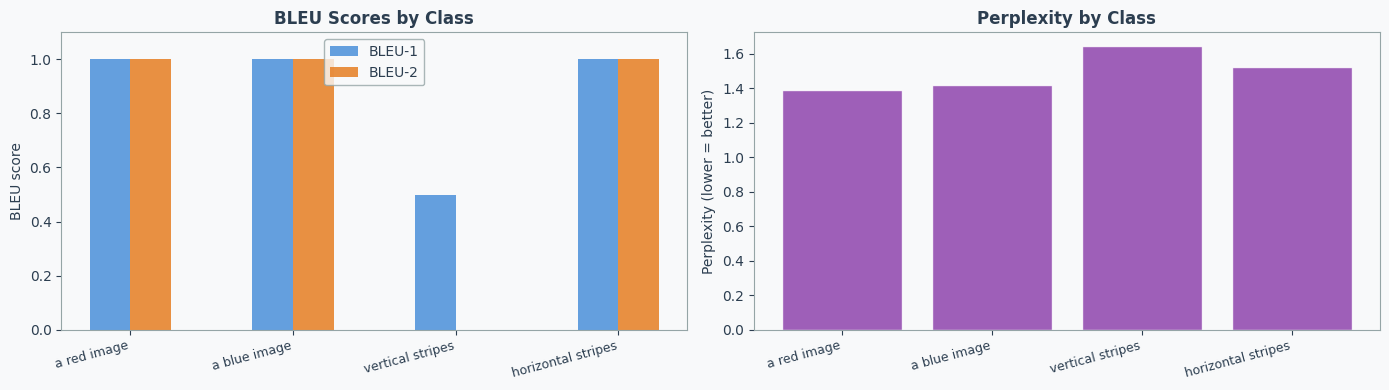

In [15]:
def plot_metrics_by_class():
    """Bar chart: BLEU-1, BLEU-2, perplexity per image class."""
    results = []
    for lbl, cap in enumerate(CAPTIONS):
        img  = make_test_image(lbl)
        pred = generate(model, tokenizer, img, strategy='greedy')
        b1   = bleu_n(pred, cap, 1)
        b2   = bleu_n(pred, cap, 2)
        ppl  = compute_perplexity(model, tokenizer, img, cap)
        results.append((cap, b1, b2, ppl))
        print(f"  pred: '{pred}' | B1={b1:.2f} B2={b2:.2f} PPL={ppl:.1f}")

    labels = [r[0] for r in results]
    b1s = [r[1] for r in results]
    b2s = [r[2] for r in results]
    ppls= [r[3] for r in results]

    x = np.arange(len(labels)); w = 0.25
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    fig.patch.set_facecolor(PAL['bg'])

    for ax in (ax1, ax2):
        ax.set_facecolor(PAL['bg'])
        ax.tick_params(colors=PAL['dark'])
        for sp in ax.spines.values(): sp.set_edgecolor(PAL['grey'])

    ax1.bar(x - w/2, b1s, w, label='BLEU-1', color=PAL['blue'],   alpha=0.85)
    ax1.bar(x + w/2, b2s, w, label='BLEU-2', color=PAL['orange'], alpha=0.85)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=15, ha='right', color=PAL['dark'], fontsize=9)
    ax1.set_ylim(0, 1.1); ax1.set_ylabel('BLEU score', color=PAL['dark'])
    ax1.set_title('BLEU Scores by Class', color=PAL['dark'], fontweight='bold')
    ax1.legend(facecolor=PAL['bg'], edgecolor=PAL['grey'], labelcolor=PAL['dark'])

    ax2.bar(x, ppls, color=PAL['purple'], alpha=0.85, edgecolor='white')
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=15, ha='right', color=PAL['dark'], fontsize=9)
    ax2.set_ylabel('Perplexity (lower = better)', color=PAL['dark'])
    ax2.set_title('Perplexity by Class', color=PAL['dark'], fontweight='bold')
    plt.tight_layout(); plt.show()

plot_metrics_by_class()


The bar chart reveals which image classes the model found easier to caption.
Classes where greedy decoding produces the exact reference caption score BLEU-1 = 1.0.
Perplexity is low for classes the model is confident about.

**BLEU-2 is always <= BLEU-1** because requiring exact bigram matches is harder than
requiring individual word matches.


### Finding the Temperature Sweet Spot

Too low a temperature produces greedy-like behavior (no diversity).
Too high a temperature produces random noise (low quality).
Let's sweep temperature from 0.1 to 2.0 and measure BLEU-1.


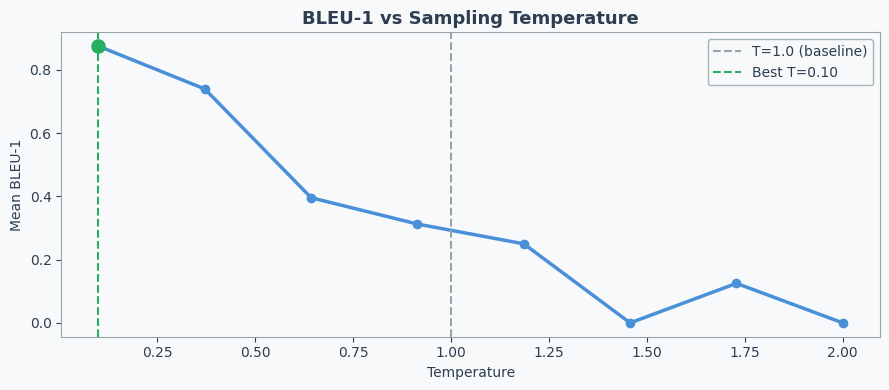

Best T=0.10  BLEU-1=0.875


In [16]:
def plot_sampling_temperature_sweep():
    """Line plot: mean BLEU-1 vs temperature (0.1 to 2.0)."""
    temps     = np.linspace(0.1, 2.0, 8)    # 8 points is enough to see the trend
    n_runs    = 2                             # 2 stochastic runs per temperature
    mean_bleu = []

    for T in temps:
        scores = []
        for _ in range(n_runs):
            for lbl, cap in enumerate(CAPTIONS):
                img  = make_test_image(lbl)
                pred = generate(model, tokenizer, img,
                                strategy='temperature', temperature=float(T))
                scores.append(bleu_n(pred, cap, 1))
        mean_bleu.append(float(np.mean(scores)))

    fig, ax = plt.subplots(figsize=(9, 4))
    fig.patch.set_facecolor(PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    ax.plot(temps, mean_bleu, color=PAL['blue'], lw=2.5, marker='o', markersize=6)
    ax.axvline(x=1.0, color=PAL['grey'], ls='--', lw=1.5, label='T=1.0 (baseline)')

    best_i = int(np.argmax(mean_bleu))
    ax.axvline(x=temps[best_i], color=PAL['green'], ls='--', lw=1.5,
               label=f'Best T={temps[best_i]:.2f}')
    ax.scatter([temps[best_i]], [mean_bleu[best_i]],
               color=PAL['green'], s=90, zorder=5)

    ax.set_xlabel('Temperature', color=PAL['dark'])
    ax.set_ylabel('Mean BLEU-1', color=PAL['dark'])
    ax.set_title('BLEU-1 vs Sampling Temperature', color=PAL['dark'],
                 fontsize=13, fontweight='bold')
    ax.legend(facecolor=PAL['bg'], edgecolor=PAL['grey'], labelcolor=PAL['dark'])
    ax.tick_params(colors=PAL['dark'])
    for sp in ax.spines.values(): sp.set_edgecolor(PAL['grey'])
    plt.tight_layout(); plt.show()
    print(f"Best T={temps[best_i]:.2f}  BLEU-1={mean_bleu[best_i]:.3f}")

plot_sampling_temperature_sweep()


The BLEU score peaks at a low temperature (close to greedy) for our short, factual
captions. As temperature increases beyond ~1.0 the model starts sampling unlikely
tokens and quality degrades.

**Practical rule of thumb:**
- Use T ~ 0.7-1.0 for factual captioning
- Use T ~ 1.2-1.5 for creative / open-ended generation


---
## Problem 4 — What Is the Model Actually Paying Attention To?

Even if we get good metrics, it's useful to *see* which image patches the model
focuses on when generating each token. This is a debugging tool — if the model
attends to the wrong patches, the metric could be high by coincidence.

We visualize the **attention weights** from the GPT decoder to the visual prefix
tokens. Each visual prefix token corresponds to one image patch.


In [17]:
@torch.no_grad()
def get_attention_maps(model, tokenizer, image):
    """
    Return per-token attention to visual prefix, collected during greedy generation.
    Returns: list of arrays (one per generated token), each of shape (n_vis,).
    """
    model.eval()
    if image.dim() == 3:
        image = image.unsqueeze(0)

    vis_prefix = model.proj(model.vit(image))   # (1, n_vis, dim)
    n_vis      = vis_prefix.size(1)
    ids        = torch.tensor([[tokenizer.bos_id]])
    all_attn   = []
    tokens_out = []

    for _ in range(20):
        logits, block_weights = model.gpt(ids, prefix=vis_prefix, return_weights=True)
        next_id = logits[0, -1].argmax().item()
        if next_id == tokenizer.eos_id:
            break
        tokens_out.append(tokenizer.i2ch.get(next_id, '?'))

        # block_weights[-1]: (1, n_heads, T_total, T_total)
        # Last text token is at position n_vis + T_text - 1 (0-indexed)
        T_text   = ids.size(1)
        w        = block_weights[-1]                      # last block
        attn_row = w[0, :, n_vis + T_text - 1, :n_vis]   # (n_heads, n_vis)
        all_attn.append(attn_row.mean(0).cpu().numpy())   # mean over heads

        ids = torch.cat([ids, torch.tensor([[next_id]])], dim=1)

    return all_attn, tokens_out


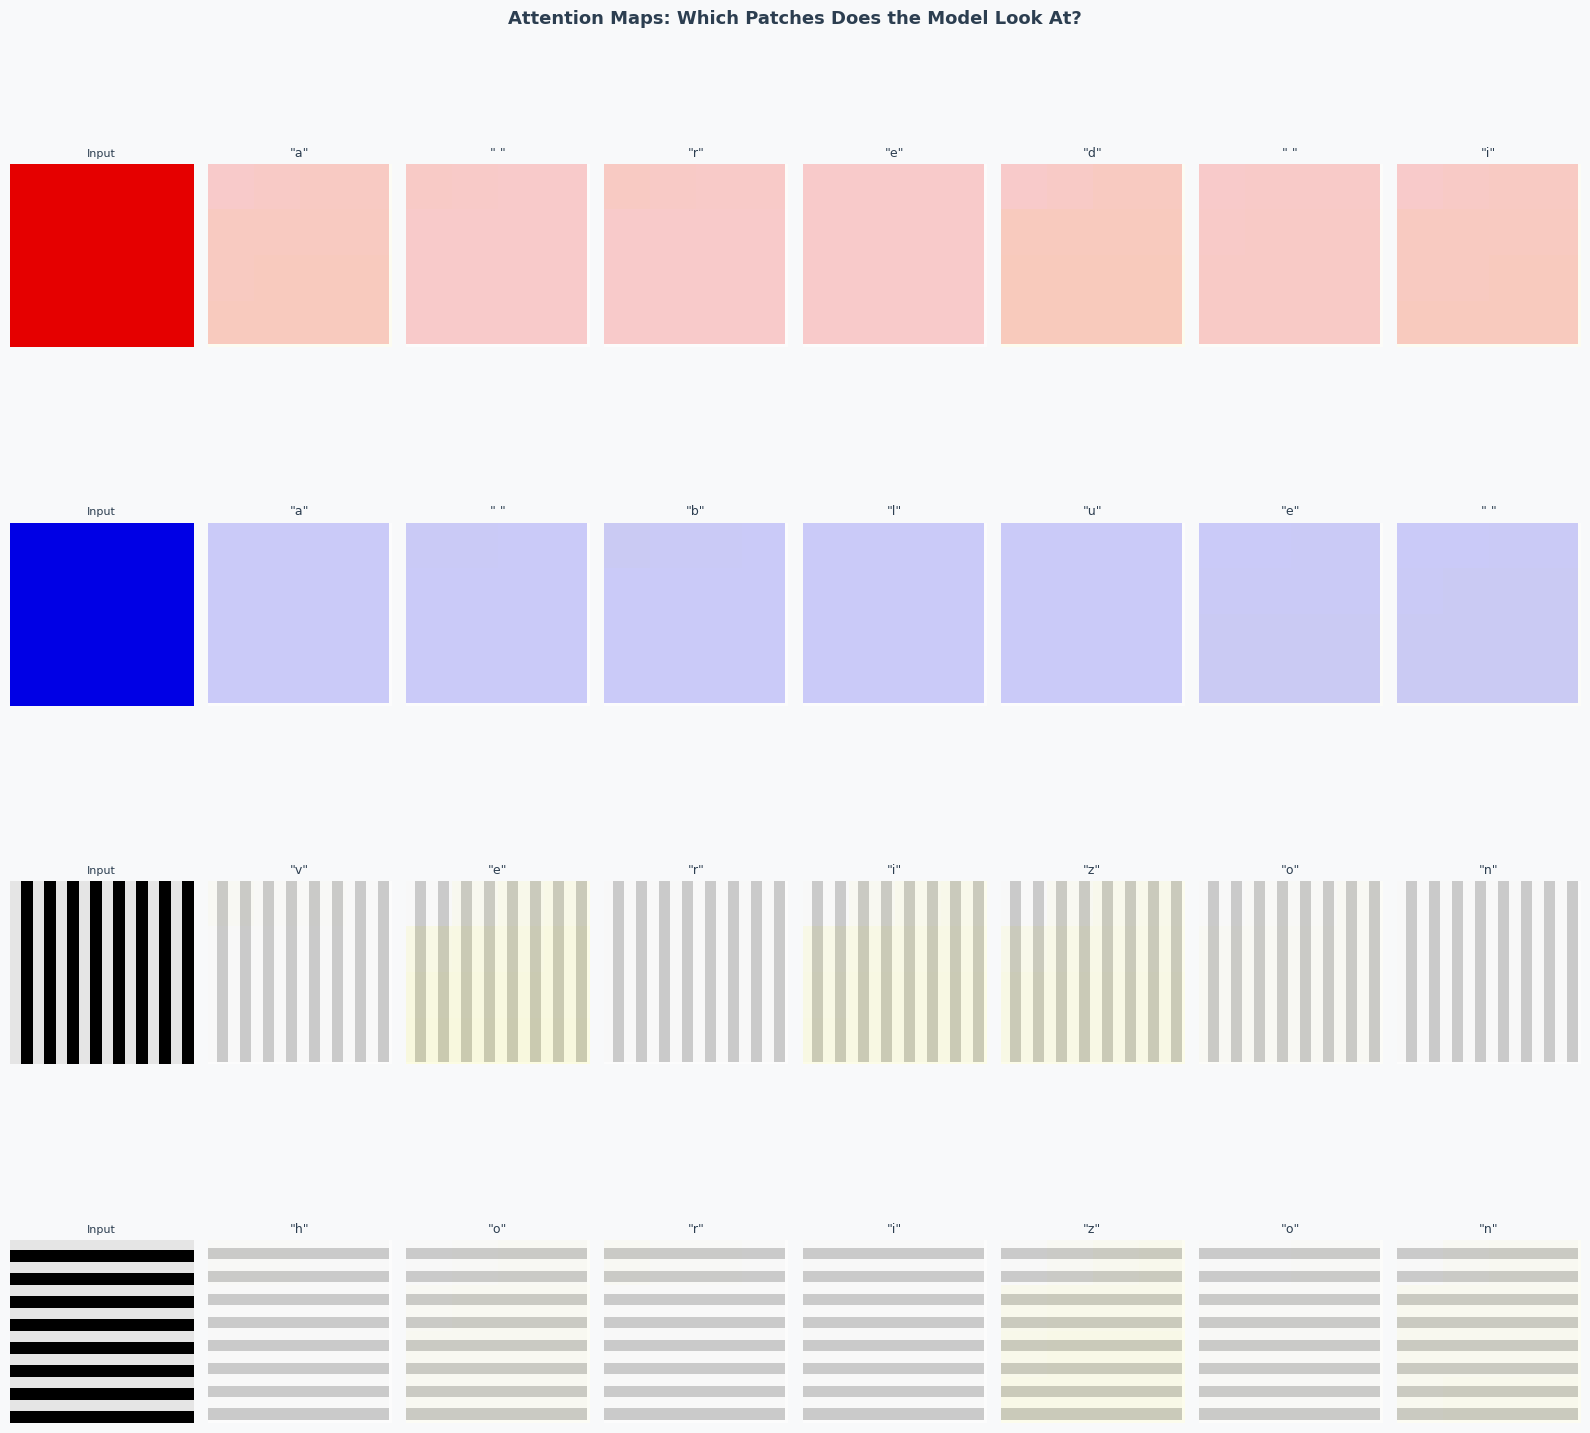

In [18]:
def plot_attention_maps():
    """Visualize patch attention overlays for each generated character."""
    patch_size = 8; img_size = 32
    n_patches  = (img_size // patch_size) ** 2   # 16
    grid_size  = img_size // patch_size           # 4

    n_rows = len(CAPTIONS)
    fig, axes = plt.subplots(n_rows, 8, figsize=(16, 4 * n_rows))
    fig.patch.set_facecolor(PAL['bg'])
    fig.suptitle('Attention Maps: Which Patches Does the Model Look At?',
                 color=PAL['dark'], fontsize=13, fontweight='bold')

    for row, label in enumerate(range(n_rows)):
        img  = make_test_image(label)
        attn_maps, toks = get_attention_maps(model, tokenizer, img)
        show = img.permute(1, 2, 0).clamp(0, 1).numpy()

        axes[row, 0].imshow(show)
        axes[row, 0].set_title('Input', color=PAL['dark'], fontsize=8)
        axes[row, 0].axis('off')

        for col in range(1, 8):
            ax = axes[row, col]
            ax.set_facecolor(PAL['bg'])
            if col - 1 < len(attn_maps):
                a = attn_maps[col - 1]
                # CLS token is at index 0; spatial patches at 1..n_patches
                a_sp = a[1:n_patches + 1] if len(a) > n_patches else a[:n_patches]
                if len(a_sp) < n_patches:
                    a_sp = np.pad(a_sp, (0, n_patches - len(a_sp)))
                a_map = a_sp.reshape(grid_size, grid_size)
                ax.imshow(show, alpha=0.5)
                ax.imshow(a_map, cmap='hot', alpha=0.6,
                          extent=[0, img_size, img_size, 0], vmin=0)
                ax.set_title(f'"{toks[col-1]}"', color=PAL['dark'], fontsize=9)
            else:
                ax.imshow(np.zeros((img_size, img_size, 3)))
            ax.axis('off')

    plt.tight_layout(); plt.show()

plot_attention_maps()


Each column shows the attention heat map for one generated character.
Brighter (hotter) patches are those the model weighted most heavily at that step.

**What to look for:**
- Does the model attend to the correct visual region for each word?
- Patches near the most visually distinctive region typically receive higher attention.

This visualization is your primary debugging tool — before improving the loss,
check whether the model is even *looking* at the right place.


---
## Bonus: Token-by-Token Generation Trace

Let's peek inside the generation loop and watch the top-3 candidates
change at each step. This demystifies the autoregressive process.


In [19]:
@torch.no_grad()
def generation_trace(model, tokenizer, image, max_steps=12):
    """Print top-3 token candidates and their probabilities at each step."""
    model.eval()
    if image.dim() == 3:
        image = image.unsqueeze(0)
    vis = model.proj(model.vit(image))
    ids = torch.tensor([[tokenizer.bos_id]])
    print(f"{'Step':>4}  {'Generated so far':30}  Top-3 candidates (prob)")
    print('-' * 70)
    for step in range(max_steps):
        logits, _ = model.gpt(ids, prefix=vis, return_weights=False)
        probs      = logits[0, -1].softmax(-1)
        top3_p, top3_i = probs.topk(3)
        so_far = tokenizer.decode(ids[0].tolist())
        cands  = '  '.join(
            f'{repr(tokenizer.i2ch.get(idx.item(), "?"))}: {p.item():.3f}'
            for idx, p in zip(top3_i, top3_p))
        print(f'{step+1:>4}  {repr(so_far):30}  {cands}')
        next_id = probs.argmax().item()
        if next_id == tokenizer.eos_id: break
        ids = torch.cat([ids, torch.tensor([[next_id]])], dim=1)

img = make_test_image(0)
generation_trace(model, tokenizer, img)


Step  Generated so far                Top-3 candidates (prob)
----------------------------------------------------------------------
   1  ''                              'a': 0.821  'v': 0.018  'd': 0.018
   2  'a'                             ' ': 0.800  'e': 0.045  'g': 0.034
   3  'a '                            'r': 0.727  'b': 0.123  'e': 0.028
   4  'a r'                           'e': 0.762  'i': 0.055  't': 0.024
   5  'a re'                          'd': 0.639  '<eos>': 0.059  'u': 0.049
   6  'a red'                         ' ': 0.757  'e': 0.043  '<eos>': 0.034
   7  'a red '                        'i': 0.777  'n': 0.047  'a': 0.034
   8  'a red i'                       'm': 0.700  't': 0.045  'i': 0.031
   9  'a red im'                      'a': 0.813  ' ': 0.032  'm': 0.022
  10  'a red ima'                     'g': 0.424  'l': 0.195  ' ': 0.069
  11  'a red imag'                    'e': 0.811  ' ': 0.042  'g': 0.028
  12  'a red image'                   '<eos>': 0.727  'r

At each step the model outputs a probability distribution over the entire vocabulary.
The `Top-3 candidates` column shows the model's belief about the next token.
Notice how confidence grows as the sequence becomes more constrained — early tokens
have lower probability while late tokens (like `<eos>`) become almost certain.


---
## Chapter Summary

| Concept | Key Idea | Code |
|---------|----------|------|
| **Greedy decoding** | Always pick argmax token | `logits.argmax()` |
| **Temperature** | Scale logits before softmax | `logits / T` |
| **Top-k sampling** | Zero out all but top k | `masked_fill(logits < threshold, -inf)` |
| **Nucleus (top-p)** | Keep tokens covering cumulative p | `cumsum(probs) > p` |
| **BLEU-n** | n-gram precision vs reference | custom `bleu_n()` |
| **Perplexity** | `exp(avg cross-entropy)` | `math.exp(loss)` |
| **Attention viz** | Which patches model focuses on | `block_weights[-1]` |

**Design principles:**
1. Decoding strategy is a *post-hoc* choice — the trained model does not change.
2. Lower temperature: safer but repetitive; higher: diverse but noisy.
3. BLEU measures *form*, not *meaning*. For real evaluation use human judges or embedding similarity.
4. Attention maps provide *interpretability* — use them to debug, not to trust blindly.

**Next chapter:** Diffusion models — an entirely different generative paradigm.
